# Exploratory Data Analysis (Section 2.6)

All 15 analyses used as evidence in the report's EDA section.

**Data stage:** the raw dataset with only the **84 exact-duplicate records removed**
(matched on `id`). No outlier treatment and no feature engineering are applied here —
those are Section 3 decisions that this exploratory analysis is intended to *motivate*.
Any `amenity_count` / pet-flag values computed below are derived **inline for plotting
only** and are not written back into the modelling pipeline.

## Setup

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

sns.set_style("whitegrid")

# figure palette
PRICE    = "#2a78d6"   # blue    - rent / price distributions
SIZE     = "#eb6834"   # orange  - square footage, bedroom & bathroom counts
LOCATION = "#1baf7a"   # aqua    - geography (states, cities)
AMENITY  = "#4a3aa7"   # violet  - amenities

CATEGORICAL = [PRICE, SIZE, LOCATION, AMENITY]   # fixed order for group comparisons
GREY = "#B0B0B0" # de-emphasised / "not specified"


def ordinal_palette(name, n):
    return sns.color_palette(name, n_colors=n + 2)[2:]

# notebooks/ runs from a different cwd than the repo root
RAW_CSV_PATH = "../data/apartments_for_rent_classified_100K/apartments_for_rent_classified_100K.csv"

# load raw (semicolon-delimited, cp1252)
df = pd.read_csv(RAW_CSV_PATH, sep=";", encoding="cp1252", low_memory=False)
print("raw rows:", len(df))

# light cleaning: exact-duplicate removal only
before = len(df)
df = df.drop_duplicates(subset=["id"], keep="first")
print(f"removed {before - len(df)} exact-duplicate listings -> {len(df)} rows")

# ensure numeric dtypes for the analytical columns
for c in ["price", "square_feet", "bathrooms", "bedrooms", "latitude", "longitude"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")


raw rows: 99492
removed 84 exact-duplicate listings -> 99408 rows


## 2.6.1 Distribution of Rental Price

Two-panel histogram: full raw range (shows extreme outliers) + restricted to < \$5,000
(shows the true right-skewed shape).

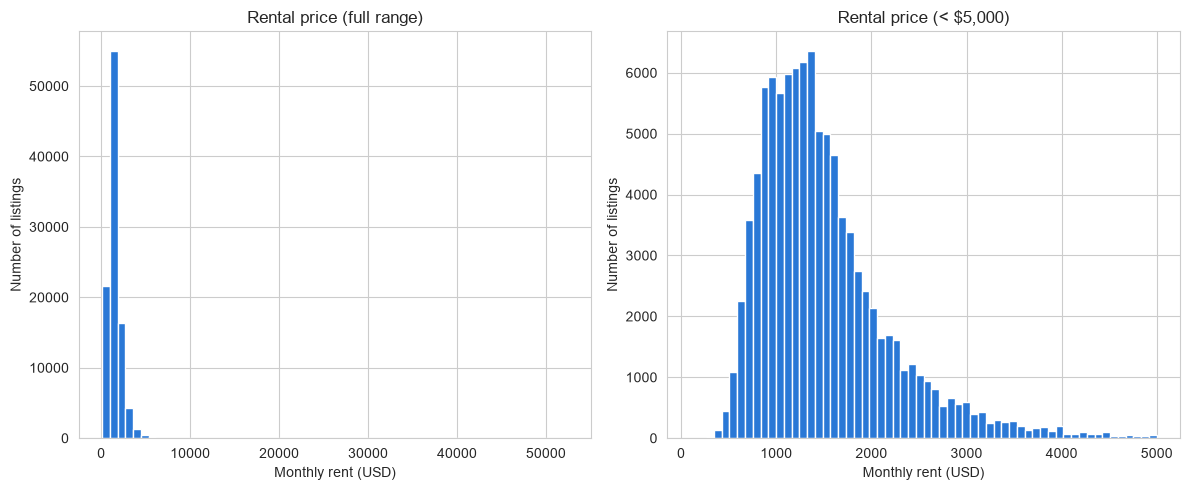

skewness: 9.96
% under $3,000: 95.5
max price: 52500.0


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["price"].dropna(), bins=60, color=PRICE, edgecolor="white")
axes[0].set_title("Rental price (full range)")
axes[0].set_xlabel("Monthly rent (USD)"); axes[0].set_ylabel("Number of listings")

sub = df[df["price"] < 5000]["price"]
axes[1].hist(sub.dropna(), bins=60, color=PRICE, edgecolor="white")
axes[1].set_title("Rental price (< $5,000)")
axes[1].set_xlabel("Monthly rent (USD)"); axes[1].set_ylabel("Number of listings")

plt.tight_layout(); plt.show()

print("skewness:", round(df["price"].skew(), 2))
print("% under $3,000:", round((df["price"] < 3000).mean() * 100, 1))
print("max price:", df["price"].max())


## 2.6.2 Correlation Between Numerical Features

Correlation matrix of the numeric features. Key finding: no single feature is strongly
correlated with price (max r ≈ 0.37) → supports non-linear models.

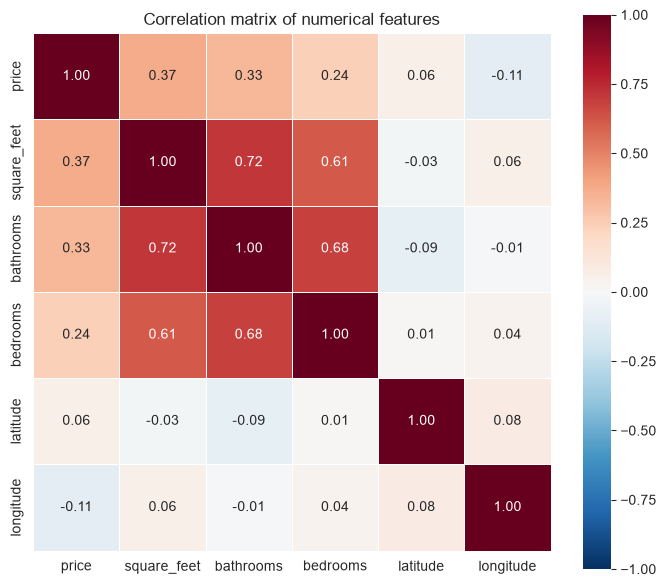

price          1.000000
square_feet    0.371692
bathrooms      0.329884
bedrooms       0.237226
latitude       0.056760
longitude     -0.106366
Name: price, dtype: float64


In [30]:
num_cols = ["price", "square_feet", "bathrooms", "bedrooms", "latitude", "longitude"]
corr = df[num_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            center=0, square=True, linewidths=.5)
plt.title("Correlation matrix of numerical features")
plt.tight_layout(); plt.show()

print(corr["price"].sort_values(ascending=False))


## 2.6.3 Price vs. Square Footage

Sampled scatter (3,000 points, < \$5,000) — loose positive relationship (r ≈ 0.34).

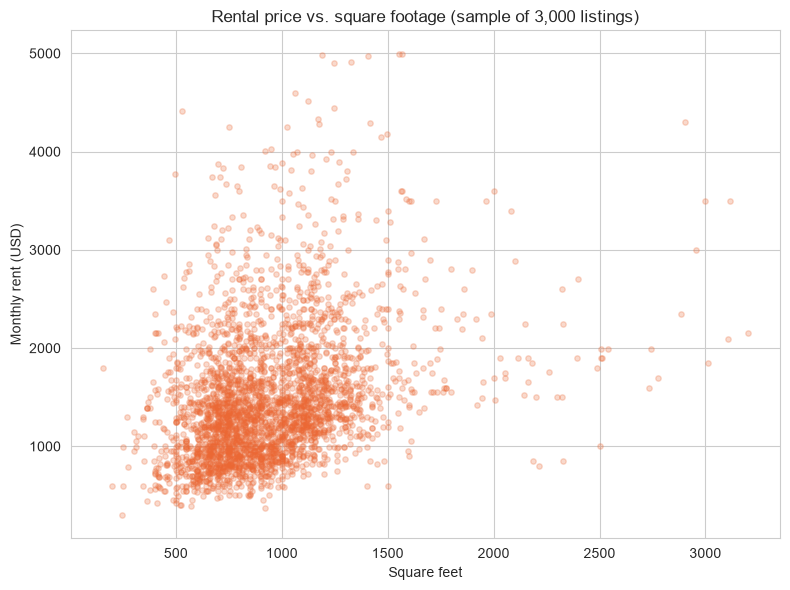

corr(square_feet, price): 0.372


In [31]:
samp = df[(df["price"] < 5000) & (df["square_feet"] < 5000)].dropna(
    subset=["price", "square_feet"])
samp = samp.sample(min(3000, len(samp)), random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(samp["square_feet"], samp["price"], alpha=0.25, s=15, color=SIZE)
plt.title("Rental price vs. square footage (sample of 3,000 listings)")
plt.xlabel("Square feet"); plt.ylabel("Monthly rent (USD)")
plt.tight_layout(); plt.show()

print("corr(square_feet, price):",
      round(df["square_feet"].corr(df["price"]), 3))


## 2.6.4 Rental Price by State

Top-10 most expensive + bottom-10 cheapest states by **median** rent
(states with ≥ 100 listings only, to avoid small-sample distortion).

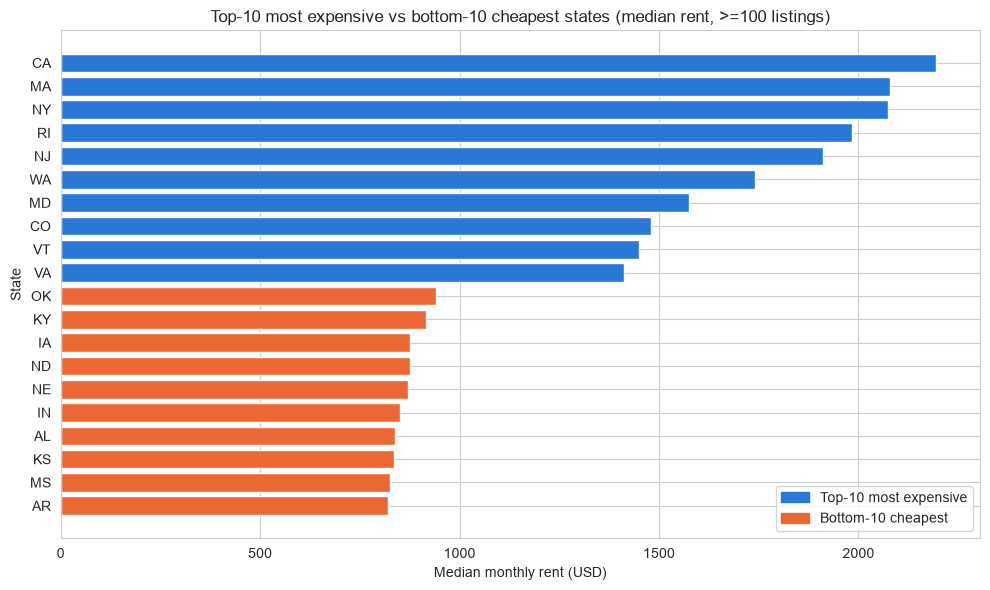

       median  count
state               
CA     2195.0  10301
MA     2080.0   5023
NY     2075.0    659
RI     1985.0    119
NJ     1910.5   4444
WA     1741.0   2595
MD     1576.0   5276
CO     1479.0   6279
VT     1450.0    125
VA     1411.0   8278
OK      940.0    934
KY      915.0    995
IA      875.0    372
ND      875.0    743
NE      871.0   1020
IN      850.0    509
AL      837.5    354
KS      835.0    899
MS      825.0    107
AR      820.0    598


In [32]:
state_stats = df.groupby("state")["price"].agg(["median", "count"])
state_stats = state_stats[state_stats["count"] >= 100].sort_values("median")

cheapest = state_stats.head(10)
expensive = state_stats.tail(10)
combined = pd.concat([expensive, cheapest]).sort_values("median", ascending=False)

colors = [PRICE if s in expensive.index else SIZE for s in combined.index]

plt.figure(figsize=(10, 6))
plt.barh(combined.index, combined["median"], color=colors)
plt.gca().invert_yaxis()
plt.legend(handles=[Patch(color=PRICE, label="Top-10 most expensive"),
                    Patch(color=SIZE, label="Bottom-10 cheapest")],
           loc="lower right", frameon=True)
plt.title("Top-10 most expensive vs bottom-10 cheapest states (median rent, >=100 listings)")
plt.xlabel("Median monthly rent (USD)"); plt.ylabel("State")
plt.tight_layout(); plt.show()

print(combined)


## 2.6.5 Rental Price by Number of Bedrooms

Boxplot (outliers hidden). Clear upward trend; studio (0 BR) is a slight non-linear quirk.

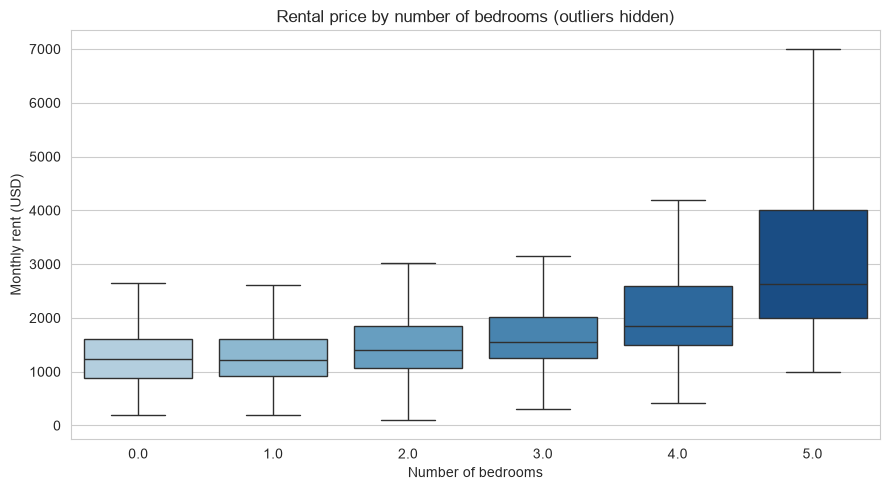

bedrooms
0.0    1245.0
1.0    1216.0
2.0    1402.0
3.0    1549.0
4.0    1845.0
5.0    2625.0
Name: price, dtype: float64


In [33]:
bed_df = df[df["bedrooms"] <= 5]

plt.figure(figsize=(9, 5))
# bedroom count is ordered, so the fill darkens with the category
bed_order = sorted(bed_df["bedrooms"].dropna().unique())
sns.boxplot(data=bed_df, x="bedrooms", y="price", order=bed_order,
            hue="bedrooms", hue_order=bed_order, legend=False,
            palette=ordinal_palette("Blues", len(bed_order)), showfliers=False)
plt.title("Rental price by number of bedrooms (outliers hidden)")
plt.xlabel("Number of bedrooms"); plt.ylabel("Monthly rent (USD)")
plt.tight_layout(); plt.show()

print(df[df["bedrooms"] <= 5].groupby("bedrooms")["price"].median())


## 2.6.6 Rental Price by Photo Status

Boxplot (outliers hidden). Negative finding: medians ~equal → has_photo not a useful predictor.

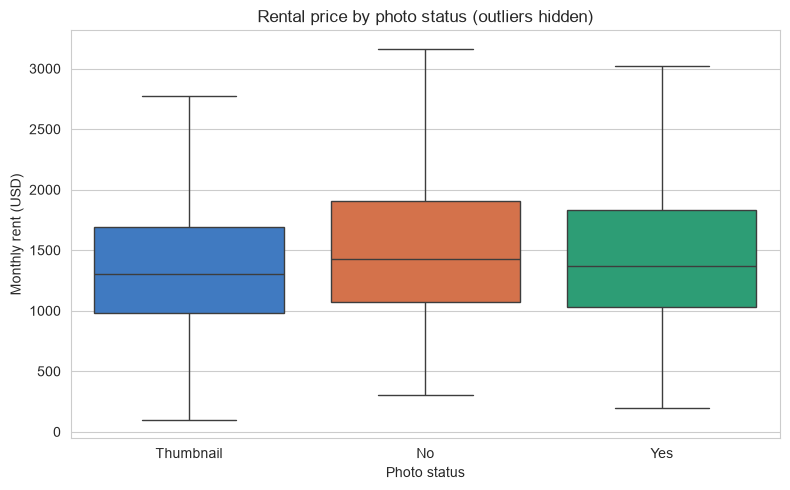

has_photo
No           1431.5
Thumbnail    1300.0
Yes          1371.0
Name: price, dtype: float64


In [34]:
plt.figure(figsize=(8, 5))
photo_order = list(df["has_photo"].dropna().unique())
sns.boxplot(data=df, x="has_photo", y="price", order=photo_order,
            hue="has_photo", hue_order=photo_order, legend=False,
            palette=CATEGORICAL[:len(photo_order)], showfliers=False)
plt.title("Rental price by photo status (outliers hidden)")
plt.xlabel("Photo status"); plt.ylabel("Monthly rent (USD)")
plt.tight_layout(); plt.show()

print(df.groupby("has_photo")["price"].median())


## 2.6.7 Geographic Distribution of Rental Prices (Choropleth)

Median rent per state (≥ 100 listings). Interactive Plotly map — screenshot to a static
image for the report.

In [35]:
import plotly.express as px

geo = df.groupby("state")["price"].agg(["median", "count"]).reset_index()
geo = geo[geo["count"] >= 100]

fig = px.choropleth(
    geo, locations="state", locationmode="USA-states",
    color="median", scope="usa", color_continuous_scale="Blues",
    labels={"median": "Median rent (USD)"},
    title="Median rental price by U.S. state (>=100 listings)",
)
fig.show()


## 2.6.8 Most Frequently Advertised Amenities

Top-20 individual amenities by frequency.

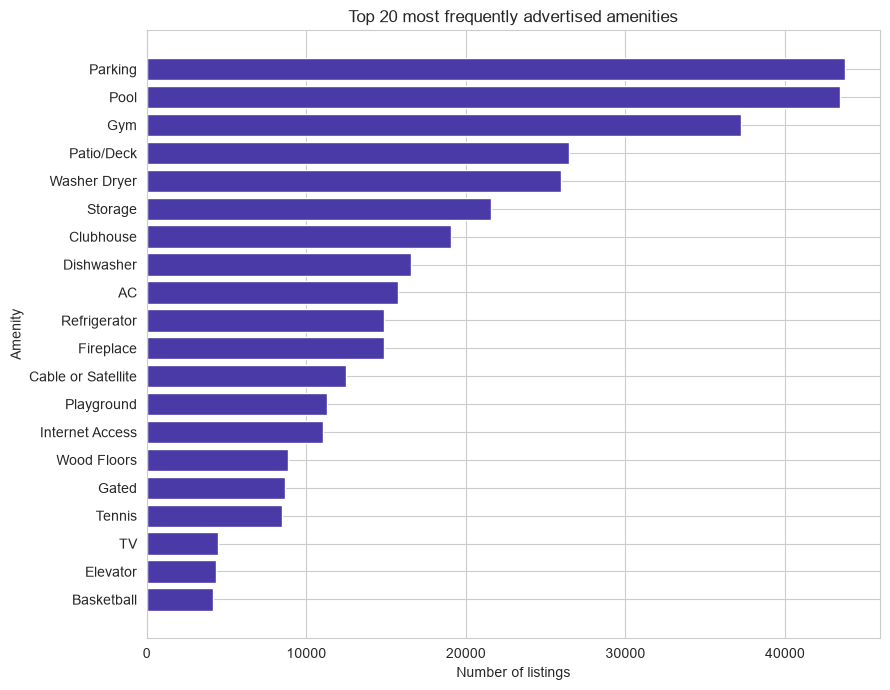

amenities
Parking               43766
Pool                  43456
Gym                   37242
Patio/Deck            26480
Washer Dryer          25934
Storage               21572
Clubhouse             19050
Dishwasher            16578
AC                    15759
Refrigerator          14893
Fireplace             14885
Cable or Satellite    12505
Playground            11315
Internet Access       11046
Wood Floors            8870
Gated                  8651
Tennis                 8467
TV                     4469
Elevator               4315
Basketball             4132
Name: count, dtype: int64


In [36]:
amen = df["amenities"].fillna("").astype(str)
exploded = (amen[amen != ""].str.split(",").explode().str.strip())
top20 = exploded.value_counts().head(20)

plt.figure(figsize=(9, 7))
plt.barh(top20.index[::-1], top20.values[::-1], color=AMENITY)
plt.title("Top 20 most frequently advertised amenities")
plt.xlabel("Number of listings"); plt.ylabel("Amenity")
plt.tight_layout(); plt.show()

print(top20)


## 2.6.9 Which Amenities Come Together (Co-occurrence)

Co-occurrence heatmap of the top-10 amenities within the same listing.

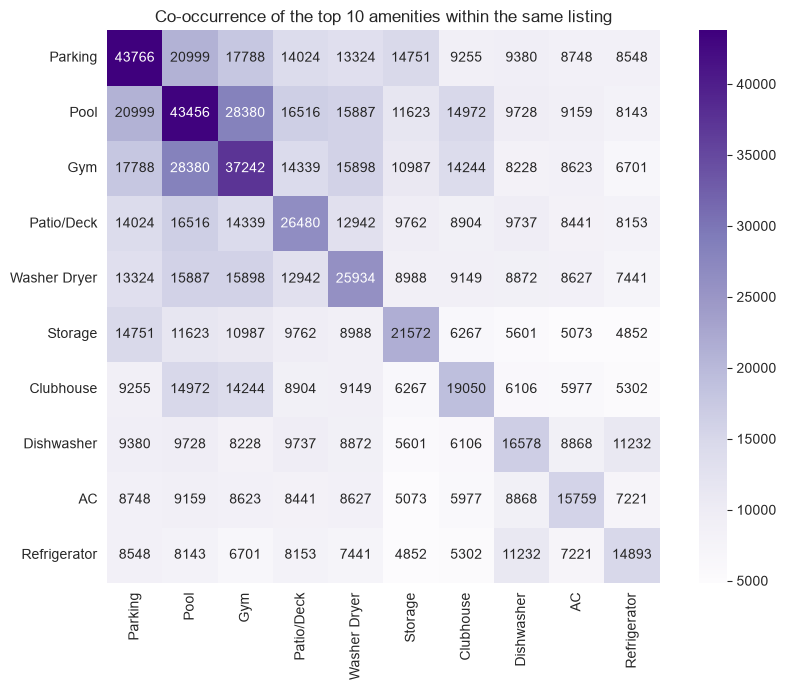

In [37]:
top10 = exploded.value_counts().head(10).index.tolist()

present = pd.DataFrame({
    a: amen.str.contains(a, regex=False).astype(int) for a in top10
})
cooc = present.T.dot(present)   # co-occurrence counts

plt.figure(figsize=(9, 7))
sns.heatmap(cooc, annot=True, fmt="d", cmap="Purples", square=True)
plt.title("Co-occurrence of the top 10 amenities within the same listing")
plt.tight_layout(); plt.show()


## 2.6.10 Bedroom–Bathroom Configuration on Market

Heatmap of listing counts by bedroom × bathroom configuration.

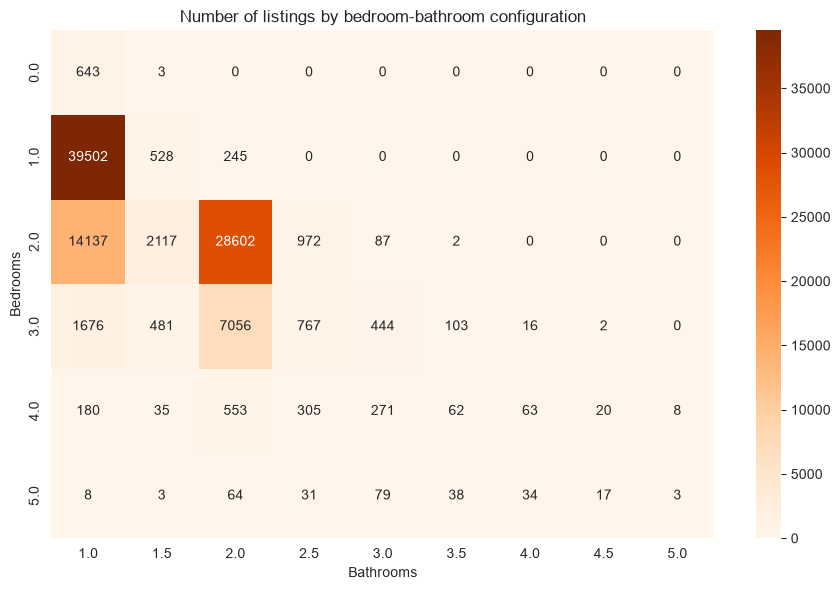

In [ ]:
conf = df[(df["bedrooms"] <= 5) & (df["bathrooms"] <= 5)]
pivot = conf.pivot_table(index="bedrooms", columns="bathrooms",
                         values="price", aggfunc="count", fill_value=0)

plt.figure(figsize=(9, 6))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Oranges")
plt.title("Number of listings by bedroom-bathroom configuration")
plt.xlabel("Bathrooms"); plt.ylabel("Bedrooms")
plt.tight_layout(); plt.show()


## 2.6.11 Apartment Size by Number of Bedrooms


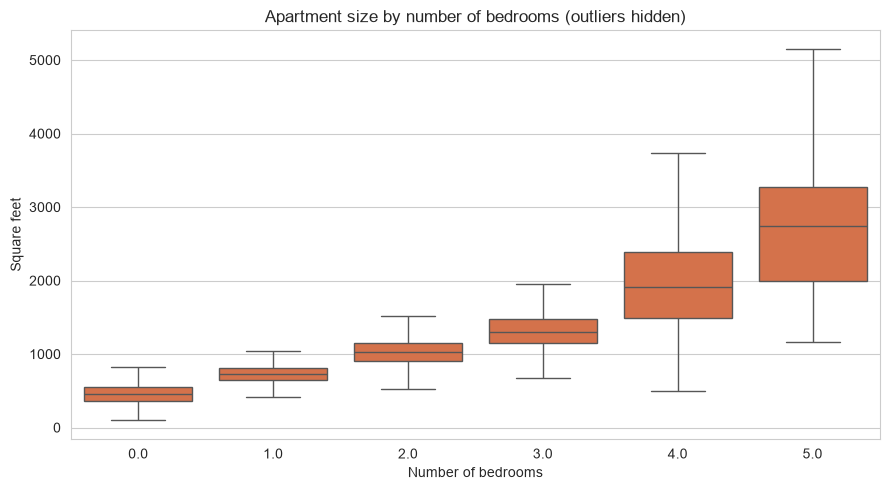

bedrooms
0.0     450.0
1.0     730.0
2.0    1033.0
3.0    1303.0
4.0    1911.0
5.0    2744.5
Name: square_feet, dtype: float64


In [39]:
bed_df = df[df["bedrooms"] <= 5]

plt.figure(figsize=(9, 5))
sns.boxplot(data=bed_df, x="bedrooms", y="square_feet", showfliers=False, color=SIZE)
plt.title("Apartment size by number of bedrooms (outliers hidden)")
plt.xlabel("Number of bedrooms"); plt.ylabel("Square feet")
plt.tight_layout(); plt.show()

print(bed_df.groupby("bedrooms")["square_feet"].median())


## 2.6.12 Top 15 Cities by Median Rent

Median rent in the 15 most-listed cities.

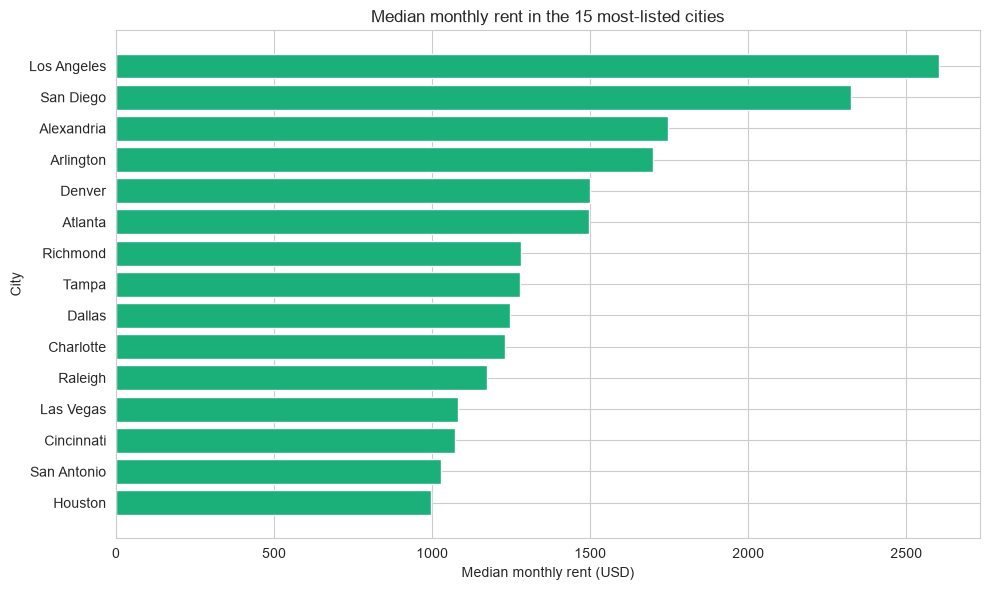

cityname
Los Angeles    2603.0
San Diego      2323.5
Alexandria     1745.0
Arlington      1700.0
Denver         1499.5
Atlanta        1495.0
Richmond       1280.0
Tampa          1279.0
Dallas         1247.0
Charlotte      1229.0
Raleigh        1173.0
Las Vegas      1080.5
Cincinnati     1072.5
San Antonio    1029.0
Houston         995.0
Name: price, dtype: float64


In [ ]:
top_cities = df["cityname"].value_counts().head(15).index
city_med = (df[df["cityname"].isin(top_cities)]
            .groupby("cityname")["price"].median()
            .sort_values(ascending=False))

plt.figure(figsize=(10, 6))
plt.barh(city_med.index[::-1], city_med.values[::-1], color=LOCATION)
plt.title("Median monthly rent in the 15 most-listed cities")
plt.xlabel("Median monthly rent (USD)"); plt.ylabel("City")
plt.tight_layout(); plt.show()

print(city_med)


## 2.6.13 Rental Price by Pet Policy (engineered flags)

**Reworked** from the raw 4-category version: the raw `Dogs`-only category has just ~126
listings, so its median is small-sample noise. Instead we group by the engineered signal
`allows_dogs` / `allows_cats` (which pool the data sensibly and tie directly to the pet
feature engineering in Section 3.4).

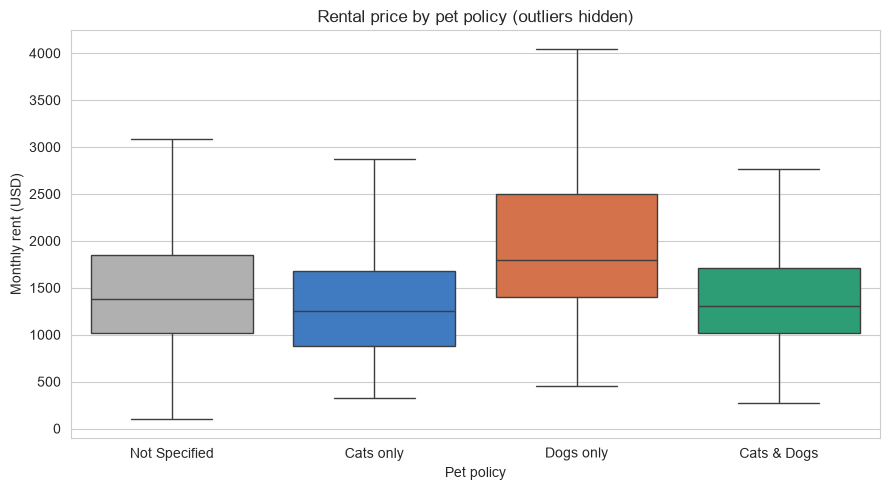

               count  median
pet_group                   
Not Specified  60374  1385.0
Cats only       1840  1250.0
Dogs only        127  1795.0
Cats & Dogs    37066  1310.0


In [ ]:
pets = df["pets_allowed"].fillna("Not Specified").astype(str)
df["allows_cats"] = pets.str.contains("Cats", regex=False).astype(int)
df["allows_dogs"] = pets.str.contains("Dogs", regex=False).astype(int)

def pet_group(row):
    if row["allows_cats"] and row["allows_dogs"]:
        return "Cats & Dogs"
    if row["allows_cats"]:
        return "Cats only"
    if row["allows_dogs"]:
        return "Dogs only"
    return "Not Specified"

df["pet_group"] = df.apply(pet_group, axis=1)

order = ["Not Specified", "Cats only", "Dogs only", "Cats & Dogs"]
plt.figure(figsize=(9, 5))
# "Not Specified" is an absence of information, not a policy -> grey
pet_colors = [GREY] + CATEGORICAL[:len(order) - 1]
sns.boxplot(data=df, x="pet_group", y="price", order=order,
            hue="pet_group", hue_order=order, legend=False,
            palette=pet_colors, showfliers=False)
plt.title("Rental price by pet policy (outliers hidden)")
plt.xlabel("Pet policy"); plt.ylabel("Monthly rent (USD)")
plt.tight_layout(); plt.show()

# report sample sizes alongside medians so reliability is explicit
print(df.groupby("pet_group")["price"].agg(["count", "median"]).reindex(order))


## 2.6.14 Distribution of Square Footage
Justifies the `square_feet` outlier treatment in Section 3.3. Extreme right skew;
max of 50,000 sq ft is an implausible data-entry error.

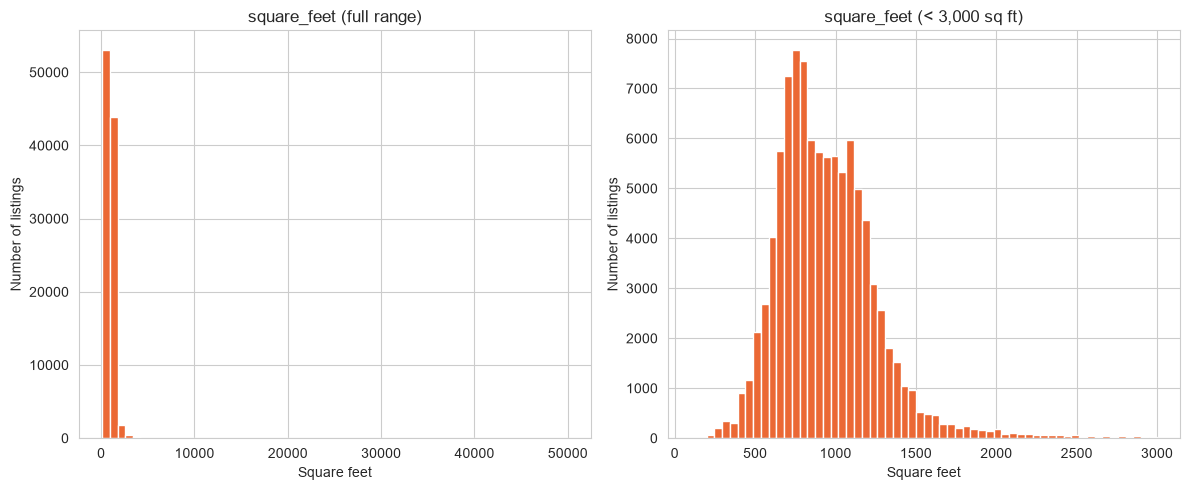

skewness: 27.12
median: 900.0 | max: 50000
% over 3000 sqft: 0.3


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["square_feet"].dropna(), bins=60, color=SIZE, edgecolor="white")
axes[0].set_title("square_feet (full range)")
axes[0].set_xlabel("Square feet"); axes[0].set_ylabel("Number of listings")

sub = df[df["square_feet"] < 3000]["square_feet"]
axes[1].hist(sub.dropna(), bins=60, color=SIZE, edgecolor="white")
axes[1].set_title("square_feet (< 3,000 sq ft)")
axes[1].set_xlabel("Square feet"); axes[1].set_ylabel("Number of listings")

plt.tight_layout(); plt.show()

print("skewness:", round(df["square_feet"].skew(), 2))
print("median:", df["square_feet"].median(), "| max:", df["square_feet"].max())
print("% over 3000 sqft:", round((df["square_feet"] > 3000).mean() * 100, 2))


## 2.6.15 Amenity Count vs. Rental Price

Closes the EDA → feature-engineering loop for Section 3.4.1: raw amenity **count** is a
weak (slightly negative) linear signal → motivates engineering individual binary amenity
flags rather than relying on the count alone.

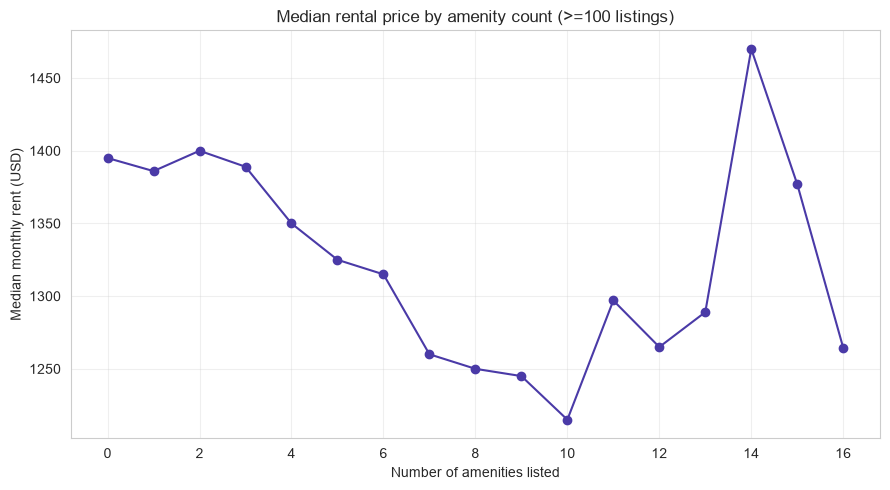

corr(amenity_count, price): -0.046


In [ ]:
amen_str = df["amenities"].fillna("None").astype(str)
df["amenity_count"] = amen_str.apply(lambda s: 0 if s == "None" else len(s.split(",")))

grp = df.groupby("amenity_count")["price"].agg(["median", "count"])
grp = grp[grp["count"] >= 100]

plt.figure(figsize=(9, 5))
plt.plot(grp.index, grp["median"], marker="o", color=AMENITY)
plt.title("Median rental price by amenity count (>=100 listings)")
plt.xlabel("Number of amenities listed"); plt.ylabel("Median monthly rent (USD)")
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("corr(amenity_count, price):",
      round(df["amenity_count"].corr(df["price"]), 3))
